# Name : Krishnakumar Mandal
Rollno : 41

Expt.-5: Disease Prediction using Naive Bayes and Neural Network with Comparison of Classifiers

In [108]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix ,roc_auc_score

In [109]:
#Load real data
data = load_breast_cancer()

# Convert to pandas DataFrame
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

x = df.drop('target',axis=1)
y = df['target']

print("Classes : " ,data.target_names)

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

Classes :  ['malignant' 'benign']


In [110]:
df.shape

(569, 31)

In [111]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [112]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Here are the KDE (Kernel Density Estimate) plots for all columns in the DataFrame. These plots show the probability density function of each variable, allowing you to visualize its distribution.

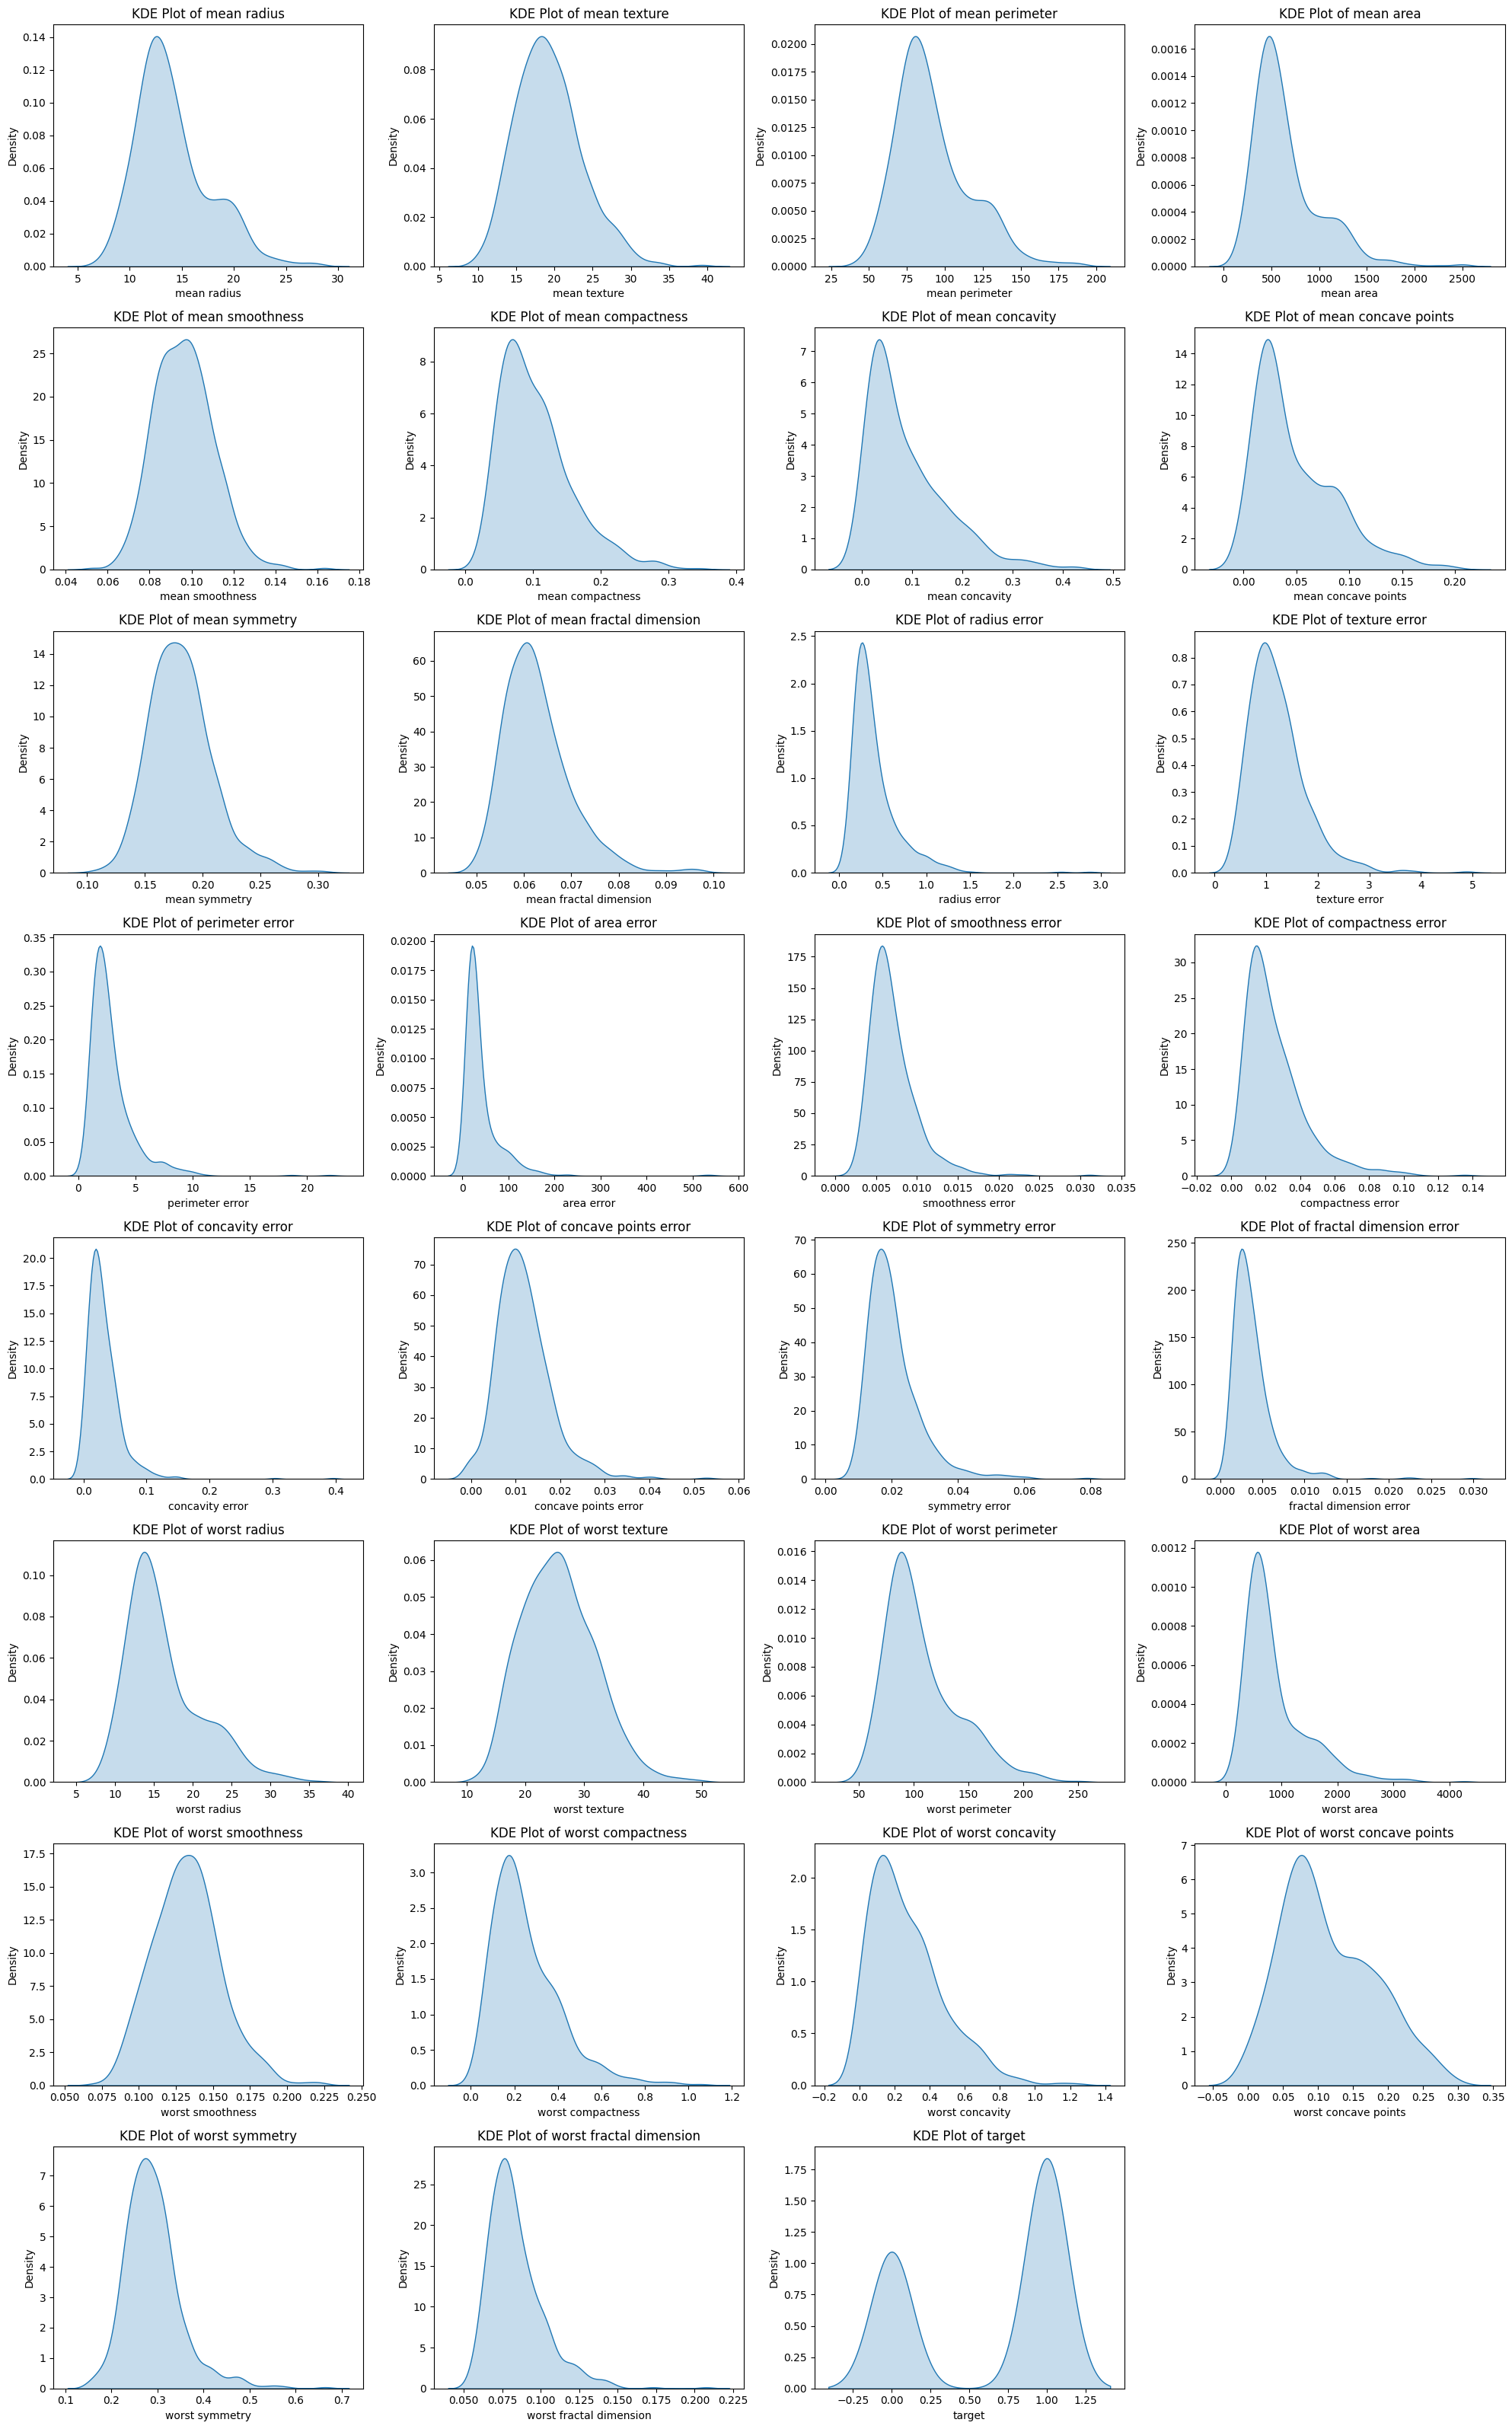

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of rows needed for subplots (4 columns per row)
num_cols_df = len(df.columns)
num_rows_plot = (num_cols_df + 3) // 4

# Create a figure and a set of subplots
fig, axes = plt.subplots(num_rows_plot, 4, figsize=(20, 4 * num_rows_plot))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Loop through each column and create a KDE plot
for i, col in enumerate(df.columns):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused subplots to prevent empty plots from showing
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [115]:
# logistic regression
lr=LogisticRegression(max_iter=5000)
lr.fit(x_train,y_train)

train_accuracy=accuracy_score(y_train,lr.predict(x_train))
pred_lr = lr.predict(x_test)
test_accuracy=accuracy_score(y_test,pred_lr)

print("train_Accuracy : " ,train_accuracy)
print("test_Accuracy : ",test_accuracy)
print("Gap between test and train accuracy :" , train_accuracy-test_accuracy)

train_Accuracy :  0.9582417582417583
test_Accuracy :  0.956140350877193
Gap between test and train accuracy : 0.002101407364565322


In [116]:
# Decision Tree
# without max_depth and min_sample_leaf causes overfitting
dt=DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)
dt.fit(x_train,y_train)

# Calculate test accuracy
pred_dt = dt.predict(x_test)
test_accuracy = accuracy_score(y_test, pred_dt)

# Calculate train accuracy using predictions on the training set
train_accuracy = accuracy_score(y_train,dt.predict(x_train))

print("train_Accuracy : " ,train_accuracy)
print("test_Accuracy : ",test_accuracy)
print("Gap between test and train accuracy :" , train_accuracy-test_accuracy)

train_Accuracy :  0.9582417582417583
test_Accuracy :  0.9473684210526315
Gap between test and train accuracy : 0.010873337189126753


In [117]:
#KNN
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

train_accuracy=accuracy_score(y_train,knn.predict(x_train))
pred_knn=knn.predict(x_test)
test_accuracy=accuracy_score(y_test,pred_knn)

print("train_Accuracy : " ,accuracy_score(y_train,knn.predict(x_train)))
print("test_Accuracy : ",accuracy_score(y_test,knn.predict(x_test)))
print("Gap between test and train accuracy :" , train_accuracy-test_accuracy)

train_Accuracy :  0.9406593406593406
test_Accuracy :  0.956140350877193
Gap between test and train accuracy : -0.015481010217852309


In [118]:
#naive bayes
nb=GaussianNB()
nb.fit(x_train,y_train)

train_accuracy=accuracy_score(y_train,nb.predict(x_train))
pred_nb=nb.predict(x_test)
test_accuracy=accuracy_score(y_test,pred_nb)

print("train_Accuracy : " ,accuracy_score(y_train,nb.predict(x_train)))
print("test_Accuracy : ",accuracy_score(y_test,nb.predict(x_test)))
print("Gap between test and train accuracy :" , train_accuracy-test_accuracy)

train_Accuracy :  0.9362637362637363
test_Accuracy :  0.9736842105263158
Gap between test and train accuracy : -0.03742047426257955


In [119]:
#Mlp
mlp=MLPClassifier(hidden_layer_sizes=(10,10,10),max_iter=1000)
mlp.fit(x_train,y_train)

test_accuracy=accuracy_score(y_test,mlp.predict(x_test))
pred_mlp=mlp.predict(x_test)
train_accuracy=accuracy_score(y_train,mlp.predict(x_train))

print("train_Accuracy : " ,train_accuracy)
print("test_Accuracy : ",test_accuracy)
print("Gap between test and train accuracy :" , train_accuracy-test_accuracy)

train_Accuracy :  0.9406593406593406
test_Accuracy :  0.9473684210526315
Gap between test and train accuracy : -0.006709080393290878


In [120]:
#Matrix of lr
precision_lr=precision_score(y_test,pred_lr)
recall_lr=recall_score(y_test,pred_lr)
f1_lr=f1_score(y_test,pred_lr)
confusion_lr=confusion_matrix(y_test,pred_lr)
roc=roc_auc_score(y_test,pred_lr)
print("confusion matrix of Logistic Regression : \n",confusion_lr)
fp_lr = confusion_lr[0, 1]  # False Positives
fn_lr = confusion_lr[1, 0]  # False Negatives
tn_lr = confusion_lr[0, 0]
tp_lr = confusion_lr[1, 1]
type1_percent_lr = (fp_lr / (tn_lr + fp_lr)) * 100 if (tn_lr + fp_lr) > 0 else 0
type2_percent_lr = (fn_lr / (fn_lr + tp_lr)) * 100 if (fn_lr + tp_lr) > 0 else 0
print(f"Type 1 Error (False Positives): {fp_lr} ({type1_percent_lr:.2f}%)")
print(f"Type 2 Error (False Negatives): {fn_lr} ({type2_percent_lr:.2f}%)")
print("precision : ",precision_lr)
print("recall : ",recall_lr)
print("f1 : ",f1_lr)
print(" roc : ",roc)

confusion matrix of Logistic Regression : 
 [[39  4]
 [ 1 70]]
Type 1 Error (False Positives): 4 (9.30%)
Type 2 Error (False Negatives): 1 (1.41%)
precision :  0.9459459459459459
recall :  0.9859154929577465
f1 :  0.9655172413793104
 roc :  0.9464461185718965


In [121]:
#matrix of Knn
precision_knn=precision_score(y_test,pred_knn)
recall_knn=recall_score(y_test,pred_knn)
f1_knn=f1_score(y_test,pred_knn)
confusion_knn=confusion_matrix(y_test,pred_knn)
roc_knn=roc_auc_score(y_test,pred_knn)
print("confusion matrix of KNN : \n",confusion_knn)
fp_knn = confusion_knn[0, 1]  # False Positives
fn_knn = confusion_knn[1, 0]  # False Negatives
tn_knn = confusion_knn[0, 0]
tp_knn = confusion_knn[1, 1]
type1_percent_knn = (fp_knn / (tn_knn + fp_knn)) * 100 if (tn_knn + fp_knn) > 0 else 0
type2_percent_knn = (fn_knn / (fn_knn + tp_knn)) * 100 if (fn_knn + tp_knn) > 0 else 0
print(f"Type 1 Error (False Positives): {fp_knn} ({type1_percent_knn:.2f}%)")
print(f"Type 2 Error (False Negatives): {fn_knn} ({type2_percent_knn:.2f}%)")
print("precision : ",precision_knn)
print("recall : ",recall_knn)
print("f1 : ",f1_knn)
print(" roc : ",roc_knn)

confusion matrix of KNN : 
 [[38  5]
 [ 0 71]]
Type 1 Error (False Positives): 5 (11.63%)
Type 2 Error (False Negatives): 0 (0.00%)
precision :  0.9342105263157895
recall :  1.0
f1 :  0.9659863945578231
 roc :  0.9418604651162791


In [122]:
#matrix of NB
precision_nb=precision_score(y_test,pred_nb)
recall_nb=recall_score(y_test,pred_nb)
f1_nb=f1_score(y_test,pred_nb)
confusion_nb=confusion_matrix(y_test,pred_nb)
roc_nb=roc_auc_score(y_test,pred_nb)
print("confusion matrix of Naive Bayes : \n",confusion_nb)
fp_nb = confusion_nb[0, 1]  # False Positives
fn_nb = confusion_nb[1, 0]  # False Negatives
tn_nb = confusion_nb[0, 0]
tp_nb = confusion_nb[1, 1]
type1_percent_nb = (fp_nb / (tn_nb + fp_nb)) * 100 if (tn_nb + fp_nb) > 0 else 0
type2_percent_nb = (fn_nb / (fn_nb + tp_nb)) * 100 if (fn_nb + tp_nb) > 0 else 0
print(f"Type 1 Error (False Positives): {fp_nb} ({type1_percent_nb:.2f}%)")
print(f"Type 2 Error (False Negatives): {fn_nb} ({type2_percent_nb:.2f}%)")
print("precision : ",precision_nb)
print("recall : ",recall_nb)
print("f1 : ",f1_nb)
print(" roc : ",roc_nb)

confusion matrix of Naive Bayes : 
 [[40  3]
 [ 0 71]]
Type 1 Error (False Positives): 3 (6.98%)
Type 2 Error (False Negatives): 0 (0.00%)
precision :  0.9594594594594594
recall :  1.0
f1 :  0.9793103448275862
 roc :  0.9651162790697674


In [123]:
#matrix of DT
precision_dt=precision_score(y_test,pred_dt)
recall_dt=recall_score(y_test,pred_dt)
f1_dt=f1_score(y_test,pred_dt)
confusion_dt=confusion_matrix(y_test,pred_dt)
roc_dt=roc_auc_score(y_test,pred_dt)
print("confusion matrix of Decision Tree : \n",confusion_dt)
fp_dt = confusion_dt[0, 1]  # False Positives
fn_dt = confusion_dt[1, 0]  # False Negatives
tn_dt = confusion_dt[0, 0]
tp_dt = confusion_dt[1, 1]
type1_percent_dt = (fp_dt / (tn_dt + fp_dt)) * 100 if (tn_dt + fp_dt) > 0 else 0
type2_percent_dt = (fn_dt / (fn_dt + tp_dt)) * 100 if (fn_dt + tp_dt) > 0 else 0
print(f"Type 1 Error (False Positives): {fp_dt} ({type1_percent_dt:.2f}%)")
print(f"Type 2 Error (False Negatives): {fn_dt} ({type2_percent_dt:.2f}%)")
print("precision : ",precision_dt)
print("recall : ",recall_dt)
print("f1 : ",f1_dt)
print(" roc : ",roc_dt)

confusion matrix of Decision Tree : 
 [[39  4]
 [ 2 69]]
Type 1 Error (False Positives): 4 (9.30%)
Type 2 Error (False Negatives): 2 (2.82%)
precision :  0.9452054794520548
recall :  0.971830985915493
f1 :  0.9583333333333334
 roc :  0.9394038650507698


In [124]:
#MLP
#matrix of NB
precision_mlp=precision_score(y_test,pred_mlp)
recall_mlp=recall_score(y_test,pred_mlp)
f1_mlp=f1_score(y_test,pred_mlp)
confusion_mlp=confusion_matrix(y_test,pred_mlp)
roc_mlp=roc_auc_score(y_test,pred_mlp)
print("confusion matrix of MLP : \n",confusion_mlp)
fp_mlp = confusion_mlp[0, 1]  # False Positives
fn_mlp = confusion_mlp[1, 0]  # False Negatives
tn_mlp = confusion_mlp[0, 0]
tp_mlp = confusion_mlp[1, 1]
type1_percent_mlp = (fp_mlp / (tn_mlp + fp_mlp)) * 100 if (tn_mlp + fp_mlp) > 0 else 0
type2_percent_mlp = (fn_mlp / (fn_mlp + tp_mlp)) * 100 if (fn_mlp + tp_mlp) > 0 else 0
print(f"Type 1 Error (False Positives): {fp_mlp} ({type1_percent_mlp:.2f}%)")
print(f"Type 2 Error (False Negatives): {fn_mlp} ({type2_percent_mlp:.2f}%)")
print("precision : ",precision_mlp)
print("recall : ",recall_mlp)
print("f1 : ",f1_mlp)
print(" roc : ",roc_mlp)

confusion matrix of MLP : 
 [[37  6]
 [ 0 71]]
Type 1 Error (False Positives): 6 (13.95%)
Type 2 Error (False Negatives): 0 (0.00%)
precision :  0.922077922077922
recall :  1.0
f1 :  0.9594594594594594
 roc :  0.9302325581395349
